Epoch 20, Loss: 0.0165
Epoch 40, Loss: 0.0086
Epoch 60, Loss: 0.0067
Epoch 80, Loss: 0.0057
Epoch 100, Loss: 0.0049
Epoch 120, Loss: 0.0041
Epoch 140, Loss: 0.0034
Epoch 160, Loss: 0.0028
Epoch 180, Loss: 0.0022
Epoch 200, Loss: 0.0017
Epoch 220, Loss: 0.0014
Epoch 240, Loss: 0.0011
Epoch 260, Loss: 0.0010
Epoch 280, Loss: 0.0010
Epoch 300, Loss: 0.0009
Epoch 320, Loss: 0.0009
Epoch 340, Loss: 0.0009
Epoch 360, Loss: 0.0009
Epoch 380, Loss: 0.0009
Epoch 400, Loss: 0.0009
Epoch 420, Loss: 0.0009
Epoch 440, Loss: 0.0009
Epoch 460, Loss: 0.0008
Epoch 480, Loss: 0.0008
Epoch 500, Loss: 0.0008


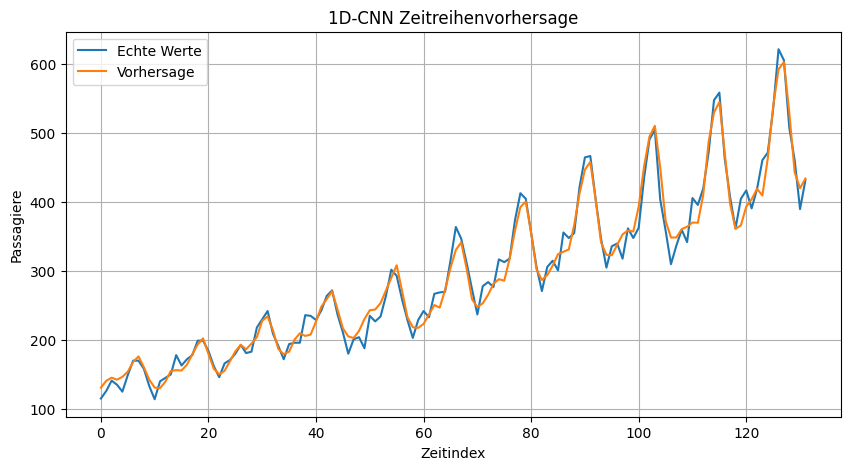

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- Daten laden ---
df = pd.read_csv("AirPassengers.csv")
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)

# --- Normalisierung ---
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# --- Zeitfenster vorbereiten ---
def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:i+window_size]
        y = data[i+window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 12
X, y = create_sequences(data, window_size)

# --- In Tensors umwandeln ---
X_tensor = torch.tensor(X).permute(0, 2, 1)  # [batch, channels, seq_len]
y_tensor = torch.tensor(y)

# --- Datensplit ---
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

# --- Modell definieren ---
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.Conv1d(16, 8, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear((window_size - 4) * 8, 1)
)

# --- Trainingsparameter ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# --- Training ---
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# --- Vorhersage ---
model.eval()
predicted = model(X_tensor).detach().numpy()
predicted = scaler.inverse_transform(predicted)
y_true = scaler.inverse_transform(y_tensor.numpy())

# --- Visualisierung ---
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_true)), y_true, label='Echte Werte')
plt.plot(range(len(predicted)), predicted, label='Vorhersage')
plt.title('1D-CNN Zeitreihenvorhersage')
plt.xlabel('Zeitindex')
plt.ylabel('Passagiere')
plt.legend()
plt.grid(True)
plt.show()


Epoch 20, Loss: 0.0070
Epoch 40, Loss: 0.0036
Epoch 60, Loss: 0.0021
Epoch 80, Loss: 0.0010
Epoch 100, Loss: 0.0007
Epoch 120, Loss: 0.0007
Epoch 140, Loss: 0.0006
Epoch 160, Loss: 0.0006
Epoch 180, Loss: 0.0006
Epoch 200, Loss: 0.0005
Epoch 220, Loss: 0.0006
Epoch 240, Loss: 0.0006
Epoch 260, Loss: 0.0005
Epoch 280, Loss: 0.0005
Epoch 300, Loss: 0.0005


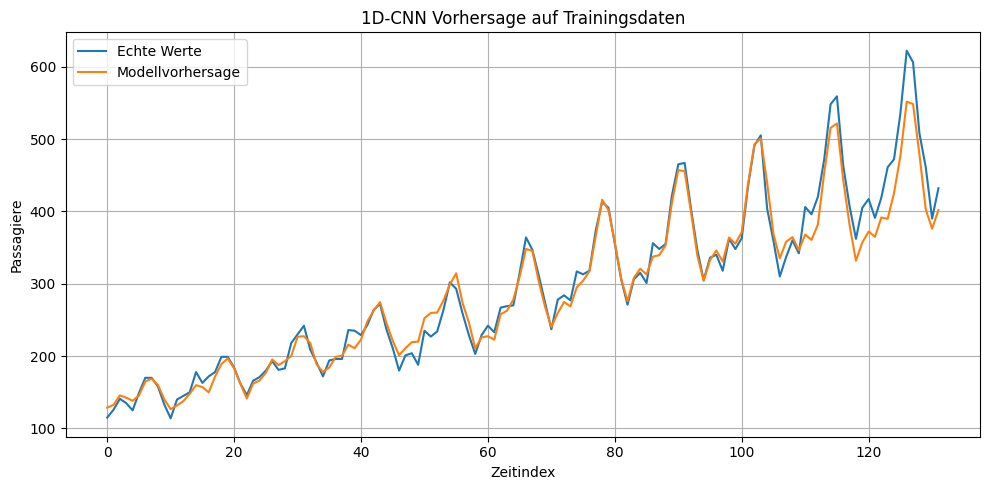

/var/folders/w6/_hp2mlcn2p5bqh2hsdp51rcc0000gn/T/ipykernel_2393/4080732327.py:106: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]


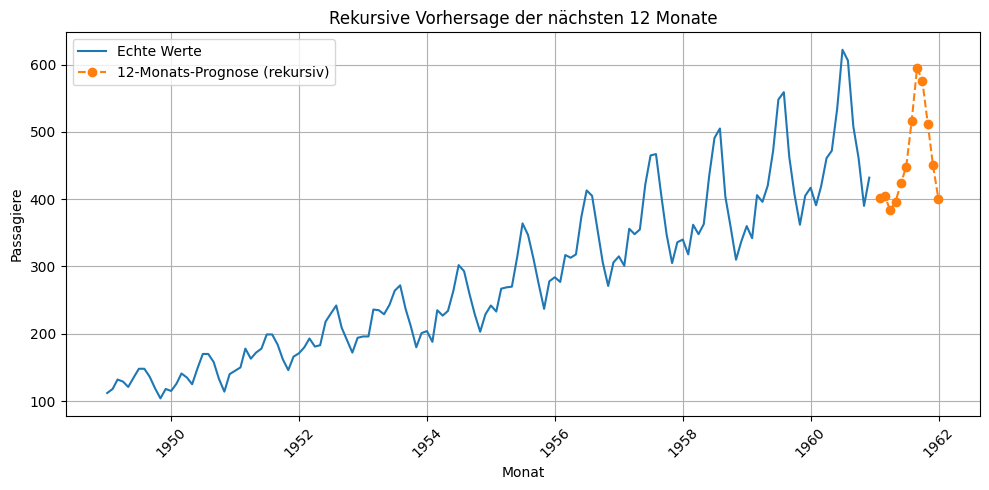

In [27]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- Daten laden ---
df = pd.read_csv("AirPassengers.csv")
data = df['Passengers'].values.astype(np.float32).reshape(-1, 1)
df['Month'] = pd.to_datetime(df['Month'])  # <-- das ist entscheidend!

# --- Normalisierung ---
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# --- Zeitfenster vorbereiten ---
def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x = data[i:i+window_size]
        y = data[i+window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 12
X, y = create_sequences(data, window_size)

# --- In Tensors umwandeln ---
X_tensor = torch.tensor(X).permute(0, 2, 1)  # [batch, channels, seq_len]
y_tensor = torch.tensor(y)

# --- Datensplit ---
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

# --- Modell definieren ---
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.Conv1d(32, 16, kernel_size=3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear((window_size - 4) * 16, 1)
)

# --- Trainingsparameter ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# --- Training ---
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# --- Vorhersage auf gesamtem Datensatz ---
model.eval()
predicted = model(X_tensor).detach().numpy()
predicted = scaler.inverse_transform(predicted)
y_true = scaler.inverse_transform(y_tensor.numpy())

# --- Visualisierung: Modell auf Trainingsdaten ---
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_true)), y_true, label='Echte Werte')
plt.plot(range(len(predicted)), predicted, label='Modellvorhersage')
plt.title('1D-CNN Vorhersage auf Trainingsdaten')
plt.xlabel('Zeitindex')
plt.ylabel('Passagiere')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Rekursive Vorhersagefunktion ---
def recursive_forecast(model, input_seq, steps, scaler):
    model.eval()
    input_seq = input_seq.clone().detach()
    predictions = []

    for _ in range(steps):
        with torch.no_grad():
            pred = model(input_seq.unsqueeze(0)).squeeze(0)
        predictions.append(pred.item())
        new_value = pred.view(1, 1)  # Form: [channels=1, seq_len=1]
        input_seq = torch.cat([input_seq[:, 1:], new_value], dim=1)

    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).ravel()

# --- Letztes echtes Fenster als Startpunkt ---
last_window = X_tensor[-1]

# --- 12 Monate vorhersagen ---
future_predictions = recursive_forecast(model, last_window, steps=12, scaler=scaler)

# --- Zeitachse für zukünftige Monate ---
last_date = pd.to_datetime(df['Month'].iloc[-1])
future_dates = pd.date_range(start=last_date, periods=13, freq='M')[1:]

# --- Visualisierung der rekursiven Vorhersage ---
plt.figure(figsize=(10, 5))
plt.plot(df['Month'], df['Passengers'], label='Echte Werte')
plt.plot(future_dates, future_predictions, label='12-Monats-Prognose (rekursiv)', linestyle='--', marker='o')
plt.title('Rekursive Vorhersage der nächsten 12 Monate')
plt.xlabel('Monat')
plt.ylabel('Passagiere')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Epoch 50/700, Loss: 0.0021
Epoch 100/700, Loss: 0.0006
Epoch 150/700, Loss: 0.0004
Epoch 200/700, Loss: 0.0003
Epoch 250/700, Loss: 0.0002
Epoch 300/700, Loss: 0.0002
Epoch 350/700, Loss: 0.0002
Epoch 400/700, Loss: 0.0002
Epoch 450/700, Loss: 0.0002
Epoch 500/700, Loss: 0.0002
Epoch 550/700, Loss: 0.0002
Epoch 600/700, Loss: 0.0002
Epoch 650/700, Loss: 0.0001
Epoch 700/700, Loss: 0.0001


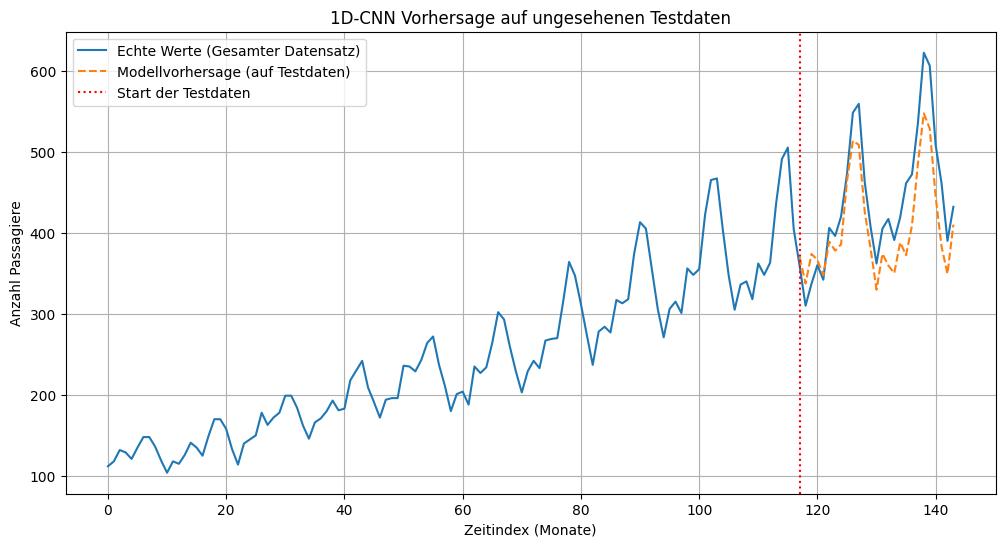

In [30]:
### Skript Start (vereinfachte Version)
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- 1. Daten laden und vorbereiten ---
df = pd.read_csv("AirPassengers.csv")
# Wir verwenden nur die Passagier-Werte
passengers = df['Passengers'].values.astype(np.float32).reshape(-1, 1)

# Normalisieren der Daten auf einen Bereich von 0-1.
# Das hilft dem Modell, schneller und stabiler zu lernen.
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(passengers)

# --- 2. Trainingssequenzen erstellen ---
# Wir erstellen Sequenzen aus den Daten. Jede Sequenz besteht aus einer Reihe
# von Werten (Eingabe) und dem darauffolgenden Wert (Ziel).
def create_sequences(data, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        # Eingabe: Eine Sequenz der Länge `window_size`
        x = data[i:(i + window_size)]
        # Ziel: Der einzelne Wert direkt nach der Sequenz
        y = data[i + window_size]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

window_size = 12  # Wir verwenden die letzten 12 Monate als Eingabe
X, y = create_sequences(data_normalized, window_size)

# --- 3. Datensplit in Training und Test ---
# Wir teilen die Daten, um das Modell fair zu bewerten.
# 80% zum Trainieren, 20% zum Testen auf ungesehenen Daten.
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- 4. In PyTorch-Tensors umwandeln ---
# Das CNN erwartet die Form [Batch, Kanäle, Sequenzlänge].
# Unsere Daten haben 1 Kanal (die Passagierzahl).
X_train_tensor = torch.from_numpy(X_train).permute(0, 2, 1)
y_train_tensor = torch.from_numpy(y_train)
X_test_tensor = torch.from_numpy(X_test).permute(0, 2, 1)
y_test_tensor = torch.from_numpy(y_test)

# --- 5. Modell definieren (vereinfacht und robust) ---
model = nn.Sequential(
    # 1. Faltungsschicht: sucht nach kleinen Mustern (Länge 3)
    nn.Conv1d(in_channels=1, out_channels=32, kernel_size=4, padding=1),
    nn.ReLU(),
    # 2. Faltungsschicht: kombiniert die ersten Muster zu größeren
    nn.Conv1d(in_channels=32, out_channels=16, kernel_size=4, padding=1),
    nn.ReLU(),
    # Adaptive Pooling: Formt die Ausgabe auf eine feste Größe (hier 1).
    # Das macht die Linear-Schicht unabhängig von window_size oder kernel_size!
    nn.AdaptiveMaxPool1d(1),
    nn.Flatten(), # Macht aus [Batch, Kanäle, 1] -> [Batch, Kanäle]
    # Lineare Schicht: Trifft die finale Vorhersage
    nn.Linear(in_features=16, out_features=1)
)

# --- 6. Modell trainieren ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
epochs = 700

for epoch in range(epochs):
    model.train() # Setzt das Modell in den Trainingsmodus
    optimizer.zero_grad()
    
    # Forward pass
    output = model(X_train_tensor)
    loss = loss_fn(output, y_train_tensor)
    
    # Backward pass und Optimierung
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# --- 7. Modell evaluieren und visualisieren ---
model.eval() # Setzt das Modell in den Evaluationsmodus (wichtig für einige Schichten)

# Wir machen Vorhersagen nur auf dem Test-Set, um die Generalisierung zu prüfen
with torch.no_grad():
    test_predictions_normalized = model(X_test_tensor)

# Rück-Normalisierung der Daten, um sie in der Originalskala darzustellen
test_predictions = scaler.inverse_transform(test_predictions_normalized.numpy())
y_test_original = scaler.inverse_transform(y_test)

# Erstellen der Zeitachse für den Plot
# Wir plotten die gesamten Originaldaten und die Vorhersage für den Test-Teil
train_size = len(y_train)
test_size = len(y_test)
time_axis = np.arange(len(passengers))
# Die Vorhersagen starten nach dem Trainings-Set und dem ersten Fenster
prediction_time_axis = np.arange(train_size + window_size, len(passengers))

plt.figure(figsize=(12, 6))
plt.plot(time_axis, passengers, label='Echte Werte (Gesamter Datensatz)')
plt.plot(prediction_time_axis, test_predictions, label='Modellvorhersage (auf Testdaten)', linestyle='--')
plt.title('1D-CNN Vorhersage auf ungesehenen Testdaten')
plt.xlabel('Zeitindex (Monate)')
plt.ylabel('Anzahl Passagiere')
plt.axvline(x=train_size+window_size, c='r', linestyle=':', label='Start der Testdaten')
plt.legend()
plt.grid(True)
plt.show()

### Skript Ende

In [ ]:
# save the pytorch model:
torch.save(model.state_dict(), 'model.pth')
# display the model architecture:
#print(model)
# print the model parameters:
#for name, param in model.named_parameters():
#    print(f"Parameter: {name}, Shape: {param.shape}")
#    print(name)
#    print(param)
test = model.named_parameters()
for name, param in test:
    if name == '0.weight':
        print(name)
        print(param[0][0])

0.weight


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.